In [1]:
import pandas as pd
import numpy as np

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer

# Clustering
from sklearn.cluster import KMeans

# Visualization
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("bakeryBasket.csv")

df.head()

,"Beer,Milk,Diapers"
0,"Bread,Butter,Milk"
1,"Milk,Diapers,Cookies"
2,"Bread,Butter,Cookies"
3,"Beer,Cookies,Diapers"
4,"Milk,Diapers,Bread,Butter"


In [6]:
# Clean + standardize column names
df.columns = df.columns.str.strip().str.lower()

print(df.columns)

Index(['beer,milk,diapers'], dtype='str')


In [12]:
print(df.columns.tolist())

['beer,milk,diapers']


In [16]:
# Import libraries
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Example dataset (you can replace this with your CSV)
data = {
    'Item': [
        'apple banana',
        'banana orange',
        'apple orange banana',
        'grape banana apple'
    ]
}

# Create DataFrame
basket = pd.DataFrame(data)

# Check it exists
print(basket.head())

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer()

# Fit and transform the 'Item' column
X = vectorizer.fit_transform(basket['Item'])

# Output shape
print("Shape of TF-IDF matrix:", X.shape)

# Optional: see feature names (words)
print("Features:", vectorizer.get_feature_names_out())

# Optional: convert to dense array to view values
print("TF-IDF Matrix:\n", X.toarray())

                  Item
0         apple banana
1        banana orange
2  apple orange banana
3   grape banana apple
Shape of TF-IDF matrix: (4, 4)
Features: ['apple' 'banana' 'grape' 'orange']
TF-IDF Matrix:
 [[0.77419109 0.63295194 0.         0.        ]
 [0.         0.55193942 0.         0.83388421]
 [0.55953044 0.4574528  0.         0.69113141]
 [0.49248889 0.40264194 0.77157901 0.        ]]


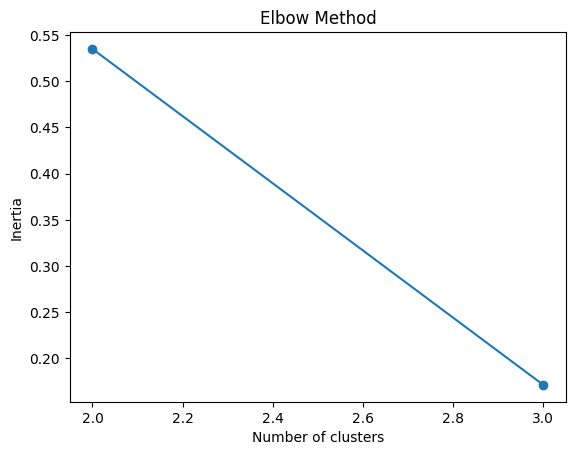

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

# Use number of samples correctly for sparse matrix
n_samples = X.shape[0]
K_range = range(2, min(n_samples, 10))

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(list(K_range), inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [20]:
terms = vectorizer.get_feature_names_out()

for i in range(k):
    print(f"\nCluster {i}:")
    center = kmeans.cluster_centers_[i]
    top_indices = center.argsort()[-10:]
    print([terms[j] for j in top_indices])


Cluster 0:
['grape', 'apple', 'banana', 'orange']

Cluster 1:
['orange', 'banana', 'apple', 'grape']

Cluster 2:
['grape', 'orange', 'banana', 'apple']


In [22]:
basket['Cluster'] = kmeans.labels_